## 1. 必要ライブラリのインポート & パス設定


In [8]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# データディレクトリ
DATA_DIR = "/mnt/c/Users/ShunK/works/CMI_comp/output/experiments/20250717_preproc_train/preprocessed"
os.listdir(DATA_DIR)

['preprocess.log',
 'preprocessor.pkl',
 'train_demographics.pkl',
 'train_info.pkl',
 'train_labels.pkl',
 'train_tabular.pkl',
 'train_tof_voxel.pkl',
 'train_tof_windows.pkl',
 'train_windows.pkl']


## 2. データのロード（例：IMUウィンドウ・Tabular・ToF）

In [9]:

# ファイル名例
with open(f"{DATA_DIR}/train_windows.pkl", "rb") as f:
    X_windows = pickle.load(f)
with open(f"{DATA_DIR}/train_tabular.pkl", "rb") as f:
    X_tabular = pickle.load(f)
with open(f"{DATA_DIR}/train_tof_voxel.pkl", "rb") as f:
    tof_voxel = pickle.load(f)
with open(f"{DATA_DIR}/train_tof_windows.pkl", "rb") as f:
    tof_windows = pickle.load(f)
with open(f"{DATA_DIR}/train_labels.pkl", "rb") as f:
    y = pickle.load(f)

print("X_windows shape:", X_windows.shape)
print("X_tabular shape:", X_tabular.shape)
print("tof_voxel shape:", tof_voxel.shape)
print("tof_windows shape:", tof_windows.shape)
print("y shape:", y.shape)

X_windows shape: (8343, 128, 18)
X_tabular shape: (8343, 389)
tof_voxel shape: (574945, 5, 8, 8)
tof_windows shape: (8343, 128, 5, 8, 8)
y shape: (8343,)



## 3. IMUウィンドウの可視化（時系列センサ値）

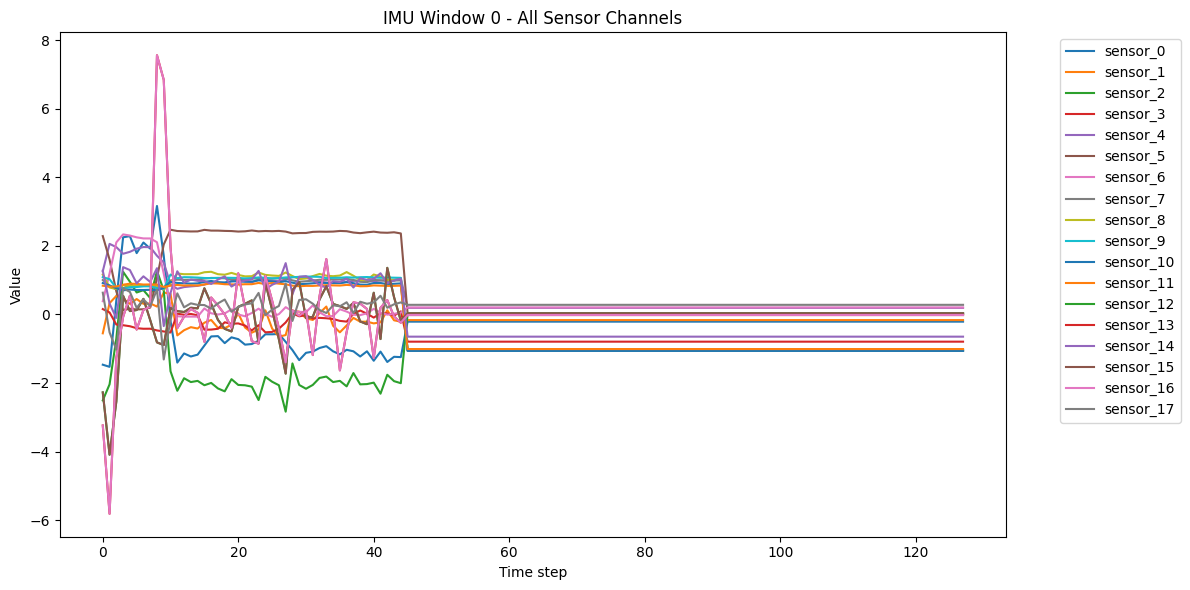

In [10]:

# 例: 最初のウィンドウの全センサ値をプロット
window_idx = 0
plt.figure(figsize=(12, 6))
for i in range(X_windows.shape[2]):
    plt.plot(X_windows[window_idx, :, i], label=f"sensor_{i}")
plt.title(f"IMU Window {window_idx} - All Sensor Channels")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 4. Tabular特徴量の分布確認

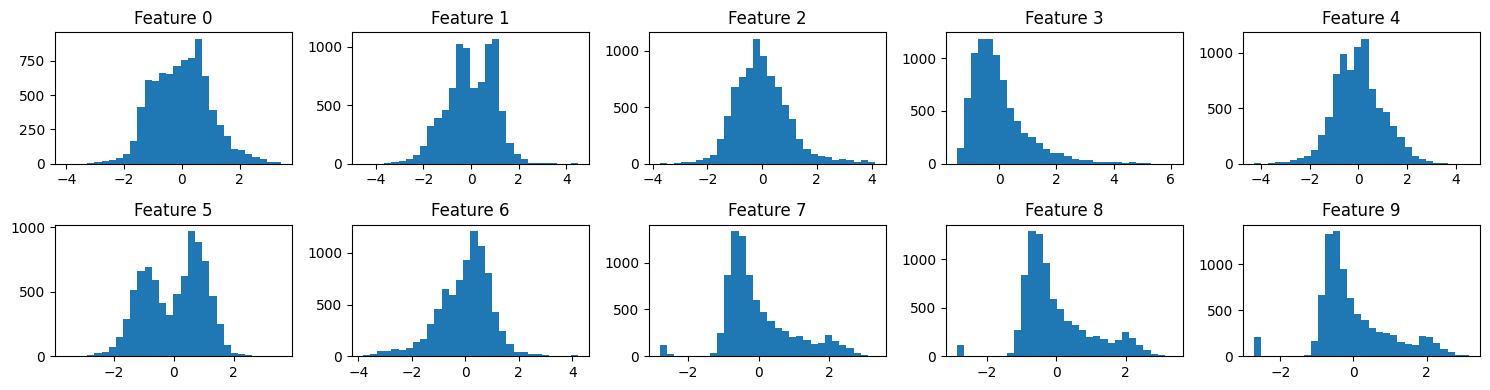

In [11]:

# 例: 最初の10特徴量のヒストグラム
plt.figure(figsize=(15, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.hist(X_tabular[:, i], bins=30)
    plt.title(f"Feature {i}")
plt.tight_layout()
plt.show()


## 5. ToFボクセルの可視化（1サンプルの3Dスライス）


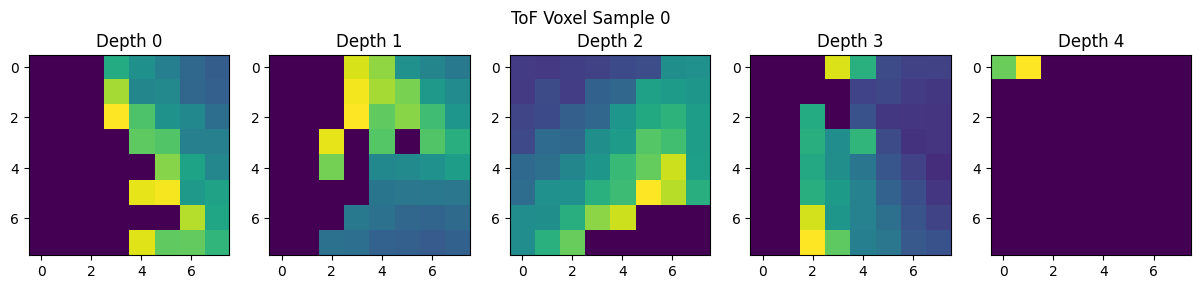

In [12]:

# 例: 1サンプル目の各depth層の8x8画像を表示
sample_idx = 0
depth = tof_voxel.shape[1]
fig, axes = plt.subplots(1, depth, figsize=(3*depth, 3))
for d in range(depth):
    axes[d].imshow(tof_voxel[sample_idx, d], cmap='viridis')
    axes[d].set_title(f"Depth {d}")
plt.suptitle(f"ToF Voxel Sample {sample_idx}")
plt.show()


## 6. ToFウィンドウの時系列的変化（アニメーション風）

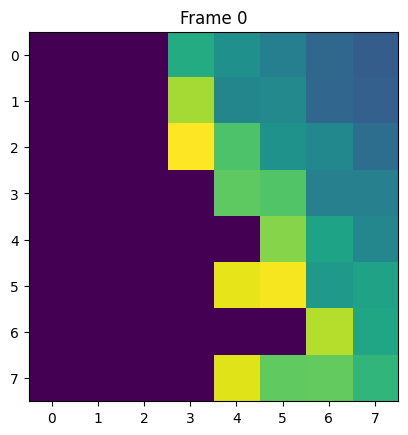

In [13]:

# 例: 1ウィンドウ内のToF画像（depth=0）を時系列で表示
from matplotlib import animation

window_idx = 0
depth_idx = 0
fig, ax = plt.subplots()
im = ax.imshow(tof_windows[window_idx, 0, depth_idx], cmap='viridis')

def update(frame):
    im.set_data(tof_windows[window_idx, frame, depth_idx])
    ax.set_title(f"Frame {frame}")
    return [im]

ani = animation.FuncAnimation(fig, update, frames=tof_windows.shape[1], interval=200, blit=True)
plt.show()


## 7. ラベル分布の確認

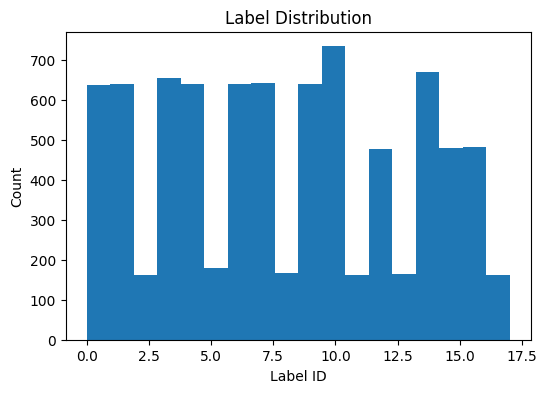

In [14]:

import collections
plt.figure(figsize=(6,4))
plt.hist(y, bins=len(np.unique(y)))
plt.title("Label Distribution")
plt.xlabel("Label ID")
plt.ylabel("Count")
plt.show()


## 1. 欠損値の確認（IMUウィンドウ・Tabular・ToF）

In [15]:

import numpy as np

# IMUウィンドウ
print("=== IMUウィンドウ ===")
print("NaN数:", np.isnan(X_windows).sum())
print("Inf数:", np.isinf(X_windows).sum())

# Tabular
print("\n=== Tabular特徴量 ===")
print("NaN数:", np.isnan(X_tabular).sum())
print("Inf数:", np.isinf(X_tabular).sum())

# ToF Voxel
print("\n=== ToF Voxel ===")
print("NaN数:", np.isnan(tof_voxel).sum())
print("Inf数:", np.isinf(tof_voxel).sum())

# ToF Windows
print("\n=== ToF Windows ===")
print("NaN数:", np.isnan(tof_windows).sum())
print("Inf数:", np.isinf(tof_windows).sum())

=== IMUウィンドウ ===
NaN数: 0
Inf数: 0

=== Tabular特徴量 ===
NaN数: 0
Inf数: 0

=== ToF Voxel ===
NaN数: 0
Inf数: 0

=== ToF Windows ===
NaN数: 0
Inf数: 0



## 2. 欠損値の分布（どのサンプル・特徴量に多いか）

/mnt/c/Users/ShunK/works/CMI_comp/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12469 (\N{KATAKANA LETTER SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/c/Users/ShunK/works/CMI_comp/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/c/Users/ShunK/works/CMI_comp/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12503 (\N{KATAKANA LETTER PU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/c/Users/ShunK/works/CMI_comp/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/c/Users/ShunK/works/CMI_comp/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.

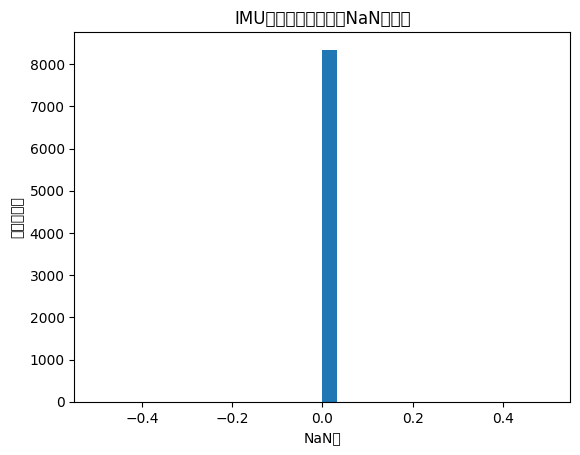

/mnt/c/Users/ShunK/works/CMI_comp/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/c/Users/ShunK/works/CMI_comp/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24500 (\N{CJK UNIFIED IDEOGRAPH-5FB4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/c/Users/ShunK/works/CMI_comp/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


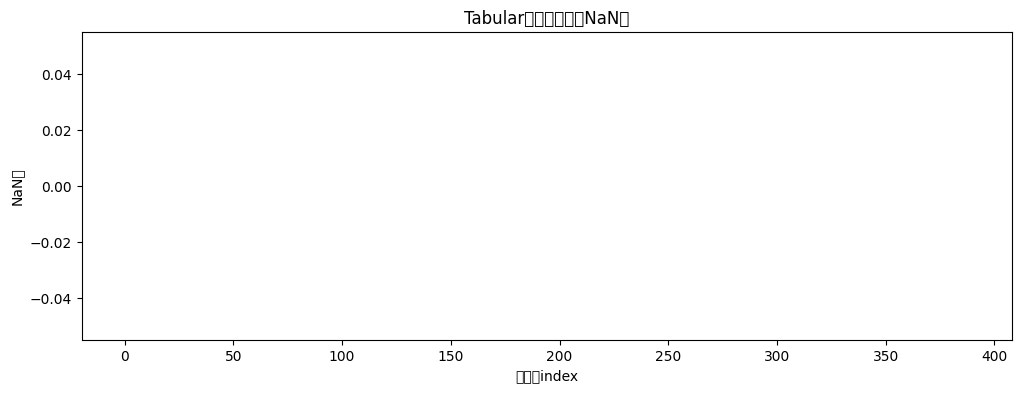

In [16]:

# IMUウィンドウ: サンプルごとのNaN数
imu_nan_per_sample = np.isnan(X_windows).sum(axis=(1,2))
plt.figure()
plt.hist(imu_nan_per_sample, bins=30)
plt.title("IMUウィンドウごとのNaN数分布")
plt.xlabel("NaN数")
plt.ylabel("サンプル数")
plt.show()

# Tabular: 特徴量ごとのNaN数
tabular_nan_per_feature = np.isnan(X_tabular).sum(axis=0)
plt.figure(figsize=(12,4))
plt.bar(range(len(tabular_nan_per_feature)), tabular_nan_per_feature)
plt.title("Tabular特徴量ごとのNaN数")
plt.xlabel("特徴量index")
plt.ylabel("NaN数")
plt.show()


## 3. 各データ全体の分布（ヒストグラム）

/mnt/c/Users/ShunK/works/CMI_comp/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38971 (\N{CJK UNIFIED IDEOGRAPH-983B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/c/Users/ShunK/works/CMI_comp/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/c/Users/ShunK/works/CMI_comp/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/c/Users/ShunK/works/CMI_comp/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/c/Users/ShunK/works/CMI_comp/.venv/lib/python3.11/site-

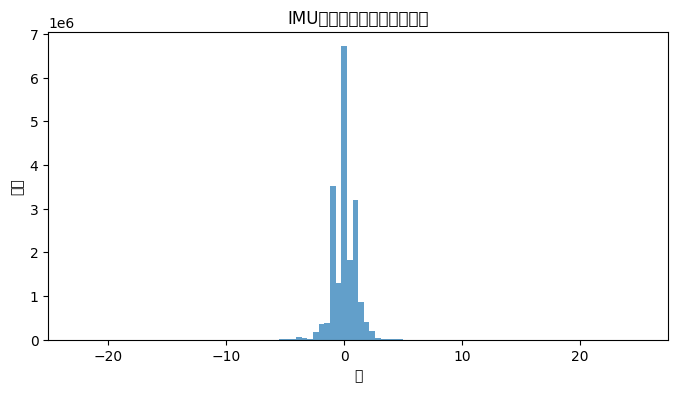

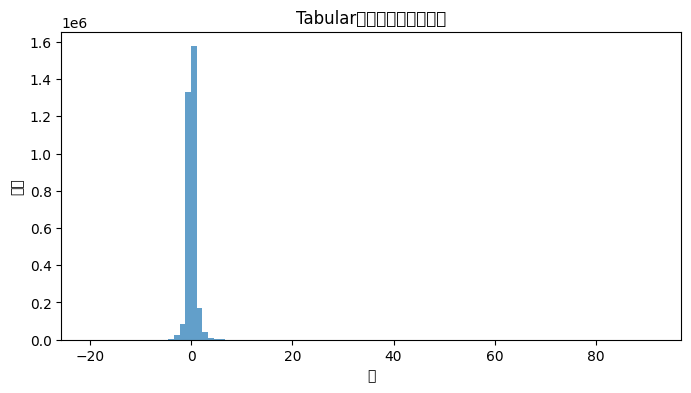

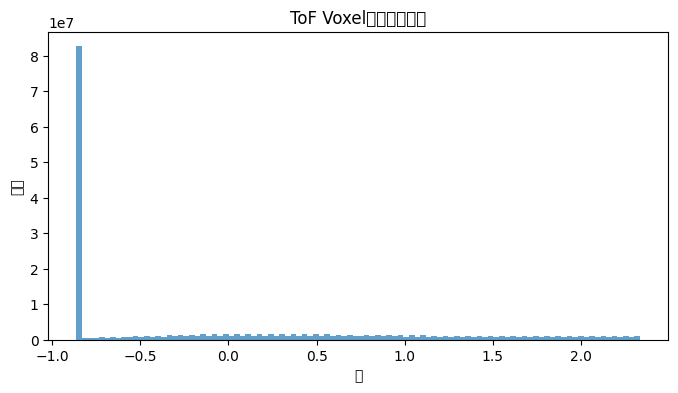

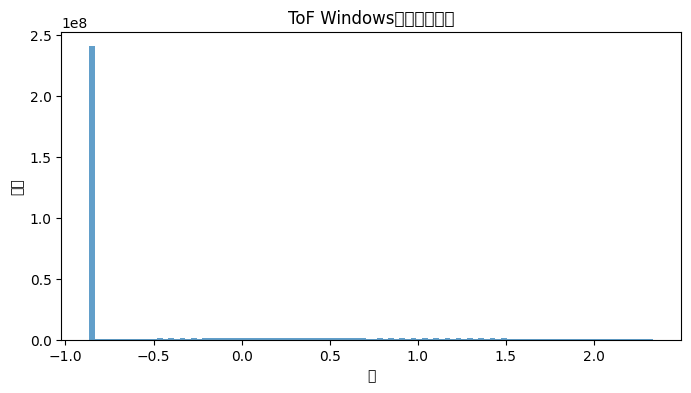

In [17]:

### IMUウィンドウ（全特徴量まとめて）

plt.figure(figsize=(8,4))
plt.hist(X_windows.flatten(), bins=100, alpha=0.7)
plt.title("IMUウィンドウ全体の値分布")
plt.xlabel("値")
plt.ylabel("頻度")
plt.show()

### Tabular特徴量（全体）
plt.figure(figsize=(8,4))
plt.hist(X_tabular.flatten(), bins=100, alpha=0.7)
plt.title("Tabular特徴量全体の値分布")
plt.xlabel("値")
plt.ylabel("頻度")
plt.show()

### ToF Voxel（全体）

plt.figure(figsize=(8,4))
plt.hist(tof_voxel.flatten(), bins=100, alpha=0.7)
plt.title("ToF Voxel全体の値分布")
plt.xlabel("値")
plt.ylabel("頻度")
plt.show()

### ToF Windows（全体）

plt.figure(figsize=(8,4))
plt.hist(tof_windows.flatten(), bins=100, alpha=0.7)
plt.title("ToF Windows全体の値分布")
plt.xlabel("値")
plt.ylabel("頻度")
plt.show()


## 4. （オプション）特徴量ごとの分布（Tabularの例）

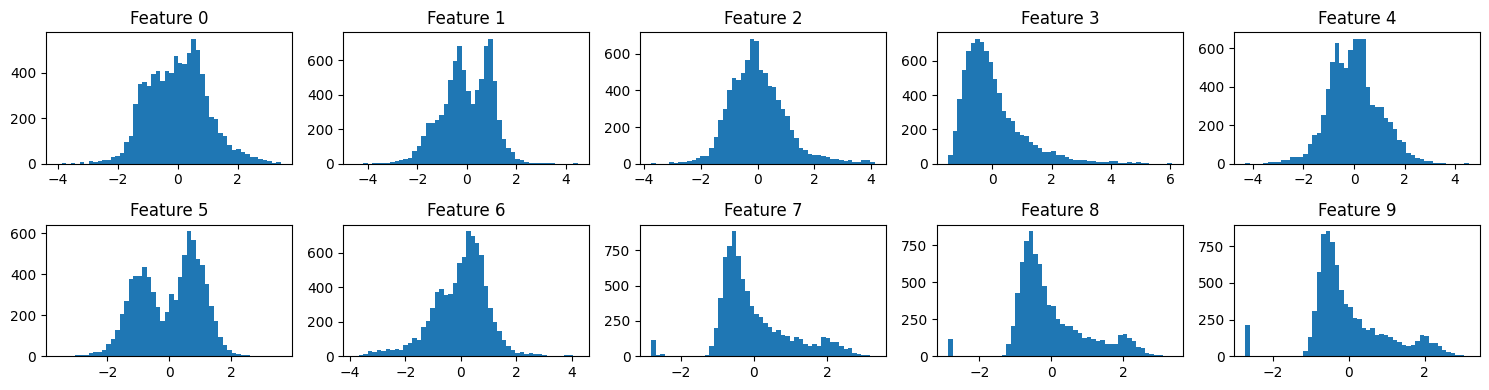

In [18]:

plt.figure(figsize=(15, 4))
for i in range(min(10, X_tabular.shape[1])):
    plt.subplot(2, 5, i+1)
    plt.hist(X_tabular[:, i], bins=50)
    plt.title(f"Feature {i}")
plt.tight_layout()
plt.show()

In [19]:



```python
```

---

これらのセルで、**欠損値の有無・分布**と**全体の値分布**が一目で分かります。  
さらに詳細な可視化や、特定のデータ・特徴量に絞った分析も可能ですので、ご要望があればお知らせください！

SyntaxError: invalid character '、' (U+3001) (3858160897.py, line 6)